## importing modules


In [99]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## data collection and preprocessing

In [100]:
data=pd.read_csv('/Users/kishan/code/genai/ml/ml_learning/datasets/Pokemon.csv')

In [101]:
data

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [102]:
df=data.drop(['Name','#','Type 1','Type 2'],axis=1)

In [103]:
df

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,318,45,49,49,65,65,45,1,False
1,405,60,62,63,80,80,60,1,False
2,525,80,82,83,100,100,80,1,False
3,625,80,100,123,122,120,80,1,False
4,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...
795,600,50,100,150,100,150,50,6,True
796,700,50,160,110,160,110,110,6,True
797,600,80,110,60,150,130,70,6,True
798,680,80,160,60,170,130,80,6,True


In [104]:
# Check the data type and unique values
print("Data type:", df['Legendary'].dtype)
print("Unique values:", df['Legendary'].unique())
print("Value counts:", df['Legendary'].value_counts())

Data type: bool
Unique values: [False  True]
Value counts: Legendary
False    735
True      65
Name: count, dtype: int64


In [105]:
df.replace({'Legendary':{False:0, True:1}}, inplace=True)

/var/folders/8k/380c1z1n5xj7p7vqw290h7v80000gn/T/ipykernel_24687/2049119638.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Legendary':{False:0, True:1}}, inplace=True)


In [106]:
df

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,318,45,49,49,65,65,45,1,0
1,405,60,62,63,80,80,60,1,0
2,525,80,82,83,100,100,80,1,0
3,625,80,100,123,122,120,80,1,0
4,309,39,52,43,60,50,65,1,0
...,...,...,...,...,...,...,...,...,...
795,600,50,100,150,100,150,50,6,1
796,700,50,160,110,160,110,110,6,1
797,600,80,110,60,150,130,70,6,1
798,680,80,160,60,170,130,80,6,1


## spliting of data into train and test data

In [107]:
X = df.drop('Legendary',axis=1)
Y= df['Legendary']

## visualizing data

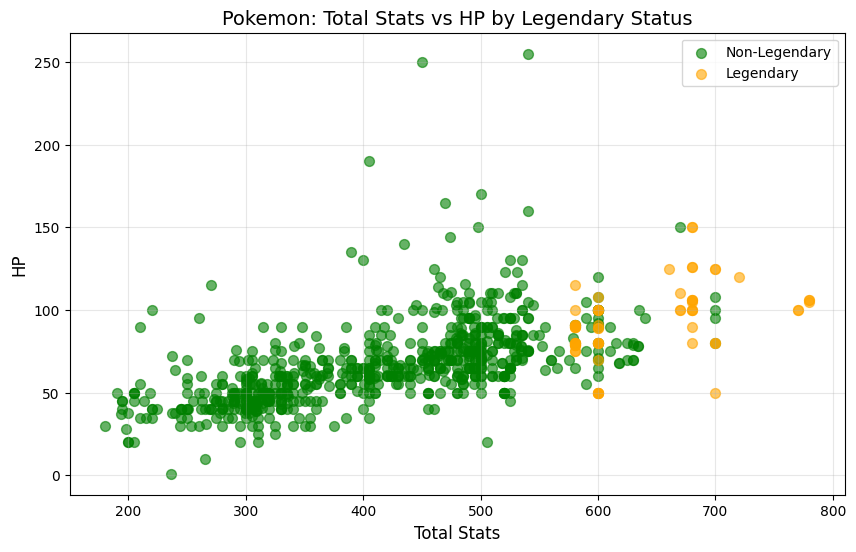

In [109]:
# Option 2: Scatter plot - Total Stats vs HP
plt.figure(figsize=(10, 6))
plt.scatter(X['Total'][Y==0], X['HP'][Y==0], alpha=0.6, label='Non-Legendary', c='green', s=50)
plt.scatter(X['Total'][Y==1], X['HP'][Y==1], alpha=0.6, label='Legendary', c='orange', s=50)
plt.xlabel('Total Stats', fontsize=12)
plt.ylabel('HP', fontsize=12)
plt.title('Pokemon: Total Stats vs HP by Legendary Status', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

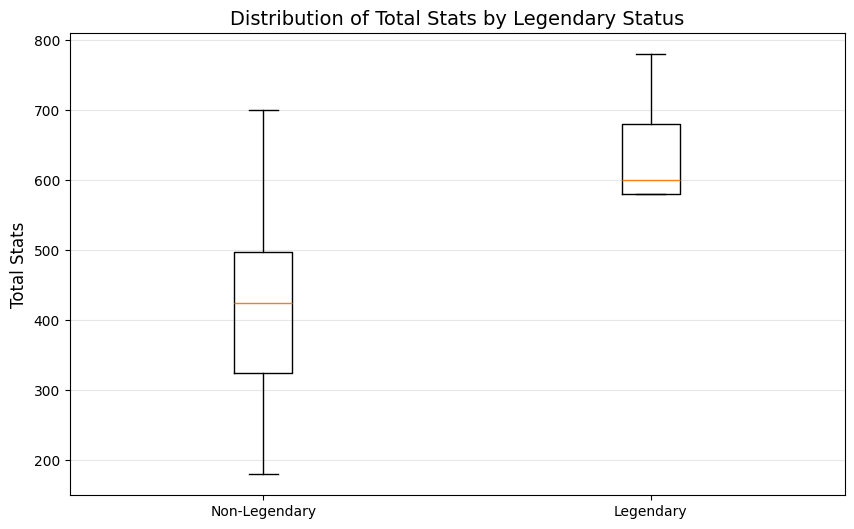

In [110]:
# Option 3: Box plot - Distribution of Total Stats
plt.figure(figsize=(10, 6))
legendary_stats = X[Y==1]['Total']
non_legendary_stats = X[Y==0]['Total']
plt.boxplot([non_legendary_stats, legendary_stats], tick_labels=['Non-Legendary', 'Legendary'])
plt.ylabel('Total Stats', fontsize=12)
plt.title('Distribution of Total Stats by Legendary Status', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## splitting data

In [111]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y, random_state=2,test_size=0.2,stratify=Y)

## model training

In [112]:
model= LogisticRegression()

In [113]:
model.fit(X_train,Y_train)

/Users/kishan/code/genai/ml/ml_learning/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## model accuracy

In [114]:
X_train_prediction=model.predict(X_train)
X_train_prediction_accuracy= accuracy_score(X_train_prediction,Y_train)

In [115]:
X_train_prediction_accuracy

0.95

In [116]:
X_test_prediction= model.predict(X_test)
X_test_prediction_accuracy= accuracy_score(Y_test,X_test_prediction)

In [117]:
X_test_prediction_accuracy

0.95625